Loaded 7881 samples from /home/ahsan/test-project/ISIC-2019/ISIC_Metadata/train_metadata_without_patches_size_shortcut.csv
  Benign    (class 1): 6310
  Malignant (class 2): 1571
Loaded 398 samples from /home/ahsan/test-project/fss/ISIC/ISIC_metadata/test_metadata_sample_data.csv
  Benign    (class 1): 199
  Malignant (class 2): 199



[Train] Unique class values in masks: [0, 1, 2]
  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)

[Test] Unique class values in masks: [0, 1, 2]
  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)

Training seed 22 on cuda:0
=> merge config from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/configs/swin_tiny_patch4_window7_224_lite.yaml
Loading Swin-Unet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/pretrained_ckpt/swin_tiny_patch4_window7_224.pth
SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.2;num_classes:3


/home/ahsan/.local/lib/python3.7/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


---final upsample expand_first---
pretrained_path:/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/pretrained_ckpt/swin_tiny_patch4_window7_224.pth
---start load pretrained modle of swin encoder---
Epoch 1/50:
  Train Loss:0.3357  Dice:0.5325  Acc:0.8789  IoU:0.3929
  Val   Loss:0.2026  Dice:0.4931  Acc:0.8595  IoU:0.3663
Epoch 10/50:
  Train Loss:0.2101  Dice:0.7019  Acc:0.9209  IoU:0.5553
  Val   Loss:0.1890  Dice:0.5287  Acc:0.8635  IoU:0.3929
Epoch 20/50:
  Train Loss:0.1886  Dice:0.7330  Acc:0.9282  IoU:0.5910
  Val   Loss:0.2016  Dice:0.4920  Acc:0.8593  IoU:0.3795
Epoch 30/50:
  Train Loss:0.1762  Dice:0.7502  Acc:0.9336  IoU:0.6151
  Val   Loss:0.1892  Dice:0.5273  Acc:0.8699  IoU:0.3985
Epoch 40/50:
  Train Loss:0.1637  Dice:0.7690  Acc:0.9365  IoU:0.6371
  Val   Loss:0.1998  Dice:0.4952  Acc:0.8635  IoU:0.3794
Epoch 50/50:
  Train Loss:0.1593  Dice:0.7757  Acc:0.9384  IoU:0.6461
  Val   Loss:0.1932  Dice:0.5159  Acc:0.8674  IoU:0.3931
Saved ch

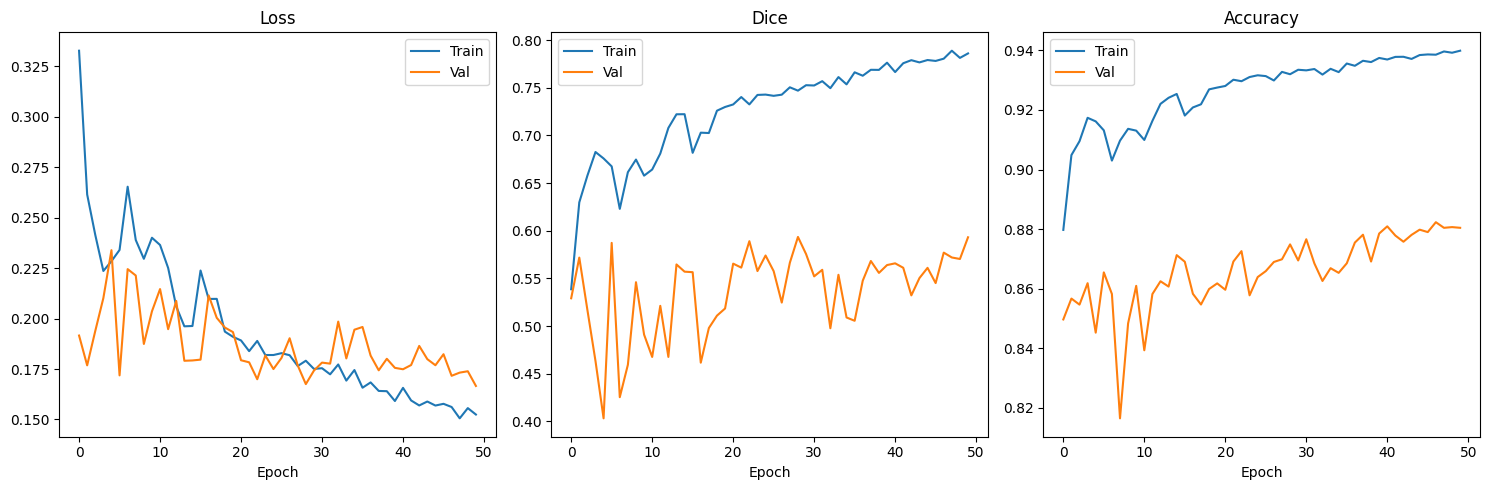

Sample 1: GT=benign  Pred=benign
Sample 2: GT=benign  Pred=benign
Sample 3: GT=benign  Pred=malignant
Sample 4: GT=benign  Pred=benign
Sample 5: GT=benign  Pred=malignant
Avg Test Dice: 0.1234


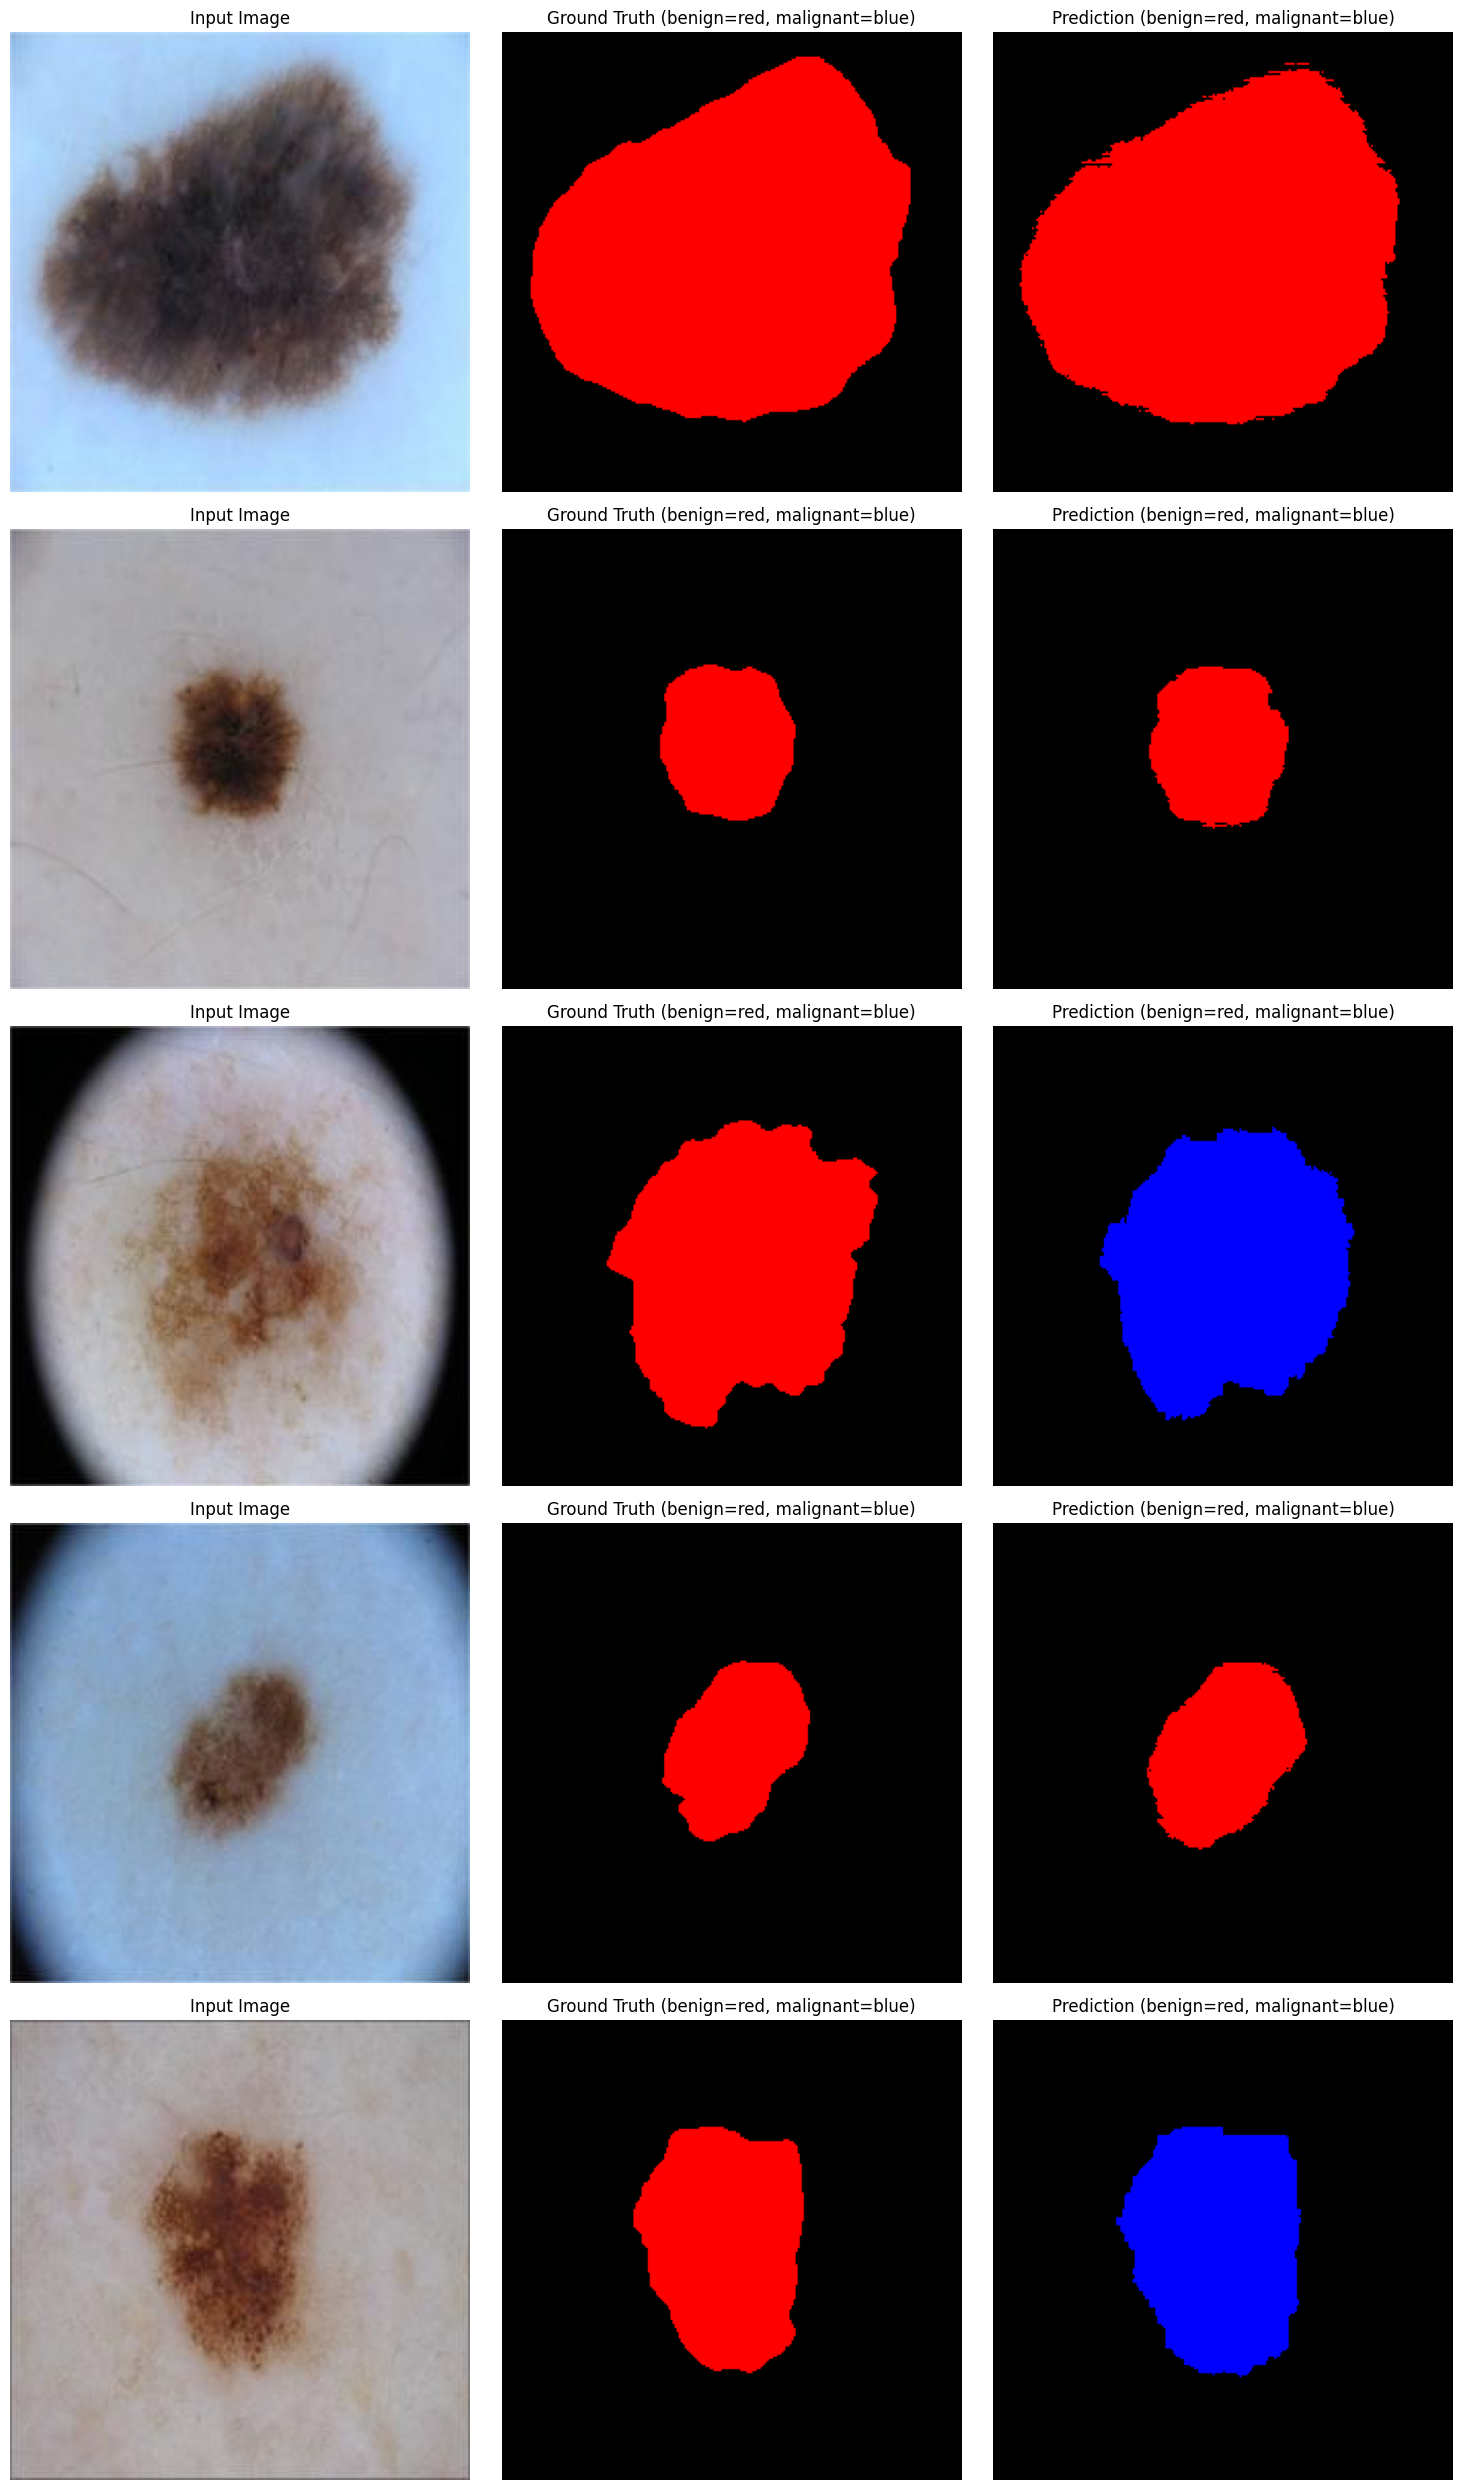


Multi-seed training complete:
  seed 22: dice=0.5159  iou=0.3931  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/checkpoints/multiseed/SwinUNet_ISIC_multiclass_seed22_epoch50_size.pth
  seed 42: dice=0.5671  iou=0.4280  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/checkpoints/multiseed/SwinUNet_ISIC_multiclass_seed42_epoch50_size.pth
  seed 123: dice=0.5931  iou=0.4572  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/checkpoints/multiseed/SwinUNet_ISIC_multiclass_seed123_epoch50_size.pth


In [2]:
"""
Swin-Unet ISIC multiclass segmentation (background / benign / malignant).
Checkpoints saved as SwinUNet_ISIC_multiclass_seed{seed}_epoch{EPOCHS}.pth
"""

import os
import sys

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import albumentations as A
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp  # DiceLoss only
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random

# Swin-Unet (https://github.com/HuCaoFighting/Swin-Unet) — pure Transformer U-Net
SWINUNET_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet"
if SWINUNET_DIR not in sys.path:
    sys.path.insert(0, SWINUNET_DIR)
from swinunet_model import build_swinunet, DEFAULT_PRETRAINED, DEFAULT_CFG

# Config (aligned with TransUNet_ISIC.ipynb)
BATCH_SIZE = 32
NUM_CLASSES = 3        # 0=background, 1=benign, 2=malignant
CLASS_NAMES = ["background", "benign", "malignant"]
EPOCHS = 50
LR_INITIAL = 1e-4
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Swin window_size=7 requires (img_size/4) and each /2 stage to be divisible by 7 (224, 448, …)
IMG_SIZE = 224
SEEDS = [22, 42, 123]
CFG_PATH = str(DEFAULT_CFG)
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
CHECKPOINT_DIR = os.path.join(SWINUNET_DIR, "checkpoints", "multiseed")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

TRAIN_IMAGE_DIR = '/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/isic_shortcut/train_shortcut_30%_without_patch/images'
TRAIN_MASK_DIR = '/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_imagefolder/isic_shortcut/train_shortcut_30%_without_patch/masks'
TRAIN_CSV = '/home/ahsan/test-project/ISIC-2019/ISIC_Metadata/train_metadata_without_patches_size_shortcut.csv'

TEST_CSV = "/home/ahsan/test-project/fss/ISIC/ISIC_metadata/test_metadata_sample_data.csv"
TEST_IMAGE_DIR = "/home/ahsan/test-project/fss/ISIC/ISIC_224_Dataset/isic_test"
TEST_MASK_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Dataset/isic_masks/test_masks"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Transforms 
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Dataset — ISIC binary mask + benign_malignant label → 3-class mask
class ISIC_Dataset(Dataset):
    def __init__(self, csv_path, image_dir, mask_dir, transform=None, img_size=224):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_size = img_size

        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        df["isic_id"] = df["isic_id"].str.strip()

        self.ids = df["isic_id"].tolist()
        self.benign_malignant = df["benign_malignant"].astype(int).tolist()

        print(f"Loaded {len(self.ids)} samples from {csv_path}")
        print(f"  Benign    (class 1): {df['benign_malignant'].eq(0).sum()}")
        print(f"  Malignant (class 2): {df['benign_malignant'].eq(1).sum()}")

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        isic_id = self.ids[idx]
        bm = self.benign_malignant[idx]  # 0=benign → class 1, 1=malignant → class 2

        img_path = os.path.join(self.image_dir, isic_id)
        mask_name = isic_id.replace(".jpg", "_segmentation.png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        binary_mask = (mask > 127).astype(np.int64)
        class_label = bm + 1
        seg_mask = binary_mask * class_label

        if self.transform:
            aug = self.transform(image=image, mask=seg_mask)
            image = aug["image"]
            mask = aug["mask"]
        else:
            mask = torch.as_tensor(seg_mask)

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        return image, mask.long()


def verify_dataset_classes(dataset, name="Dataset", n_batches=10):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    all_classes = set()
    for i, (_, masks) in enumerate(loader):
        for v in masks.unique().tolist():
            all_classes.add(int(v))
        if i >= n_batches:
            break
    print(f"\n[{name}] Unique class values in masks: {sorted(all_classes)}")
    if 2 not in all_classes:
        print("  *** WARNING: class 2 (malignant) NOT found — check benign_malignant column ***")
    else:
        print("  OK — all 3 classes present (0=bg, 1=benign, 2=malignant)")


ISIC_train_dataset = ISIC_Dataset(
    csv_path=TRAIN_CSV,
    image_dir=TRAIN_IMAGE_DIR,
    mask_dir=TRAIN_MASK_DIR,
    transform=train_transform,
    img_size=IMG_SIZE,
)
ISIC_test_dataset = ISIC_Dataset(
    csv_path=TEST_CSV,
    image_dir=TEST_IMAGE_DIR,
    mask_dir=TEST_MASK_DIR,
    transform=val_transform,
    img_size=IMG_SIZE,
)

verify_dataset_classes(ISIC_train_dataset, name="Train")
verify_dataset_classes(ISIC_test_dataset, name="Test")

train_loader = DataLoader(
    ISIC_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    ISIC_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
val_loader = test_loader

criterion = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

# Metrics
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    preds        = outputs.argmax(dim=1)
    acc          = (preds == masks).float().mean().item()
    preds_flat   = preds.view(-1)
    masks_flat   = masks.view(-1)
    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()
    inter         = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds   = preds_one_hot.sum(dim=0)
    total_masks   = masks_one_hot.sum(dim=0)
    union         = total_preds + total_masks - inter

    # Skip background (index 0)
    inter       = inter[1:]
    union       = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)
    if class_present.sum() == 0:
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class  = (inter + smooth) / (union + smooth)

    return {
        "acc"  : acc,
        "dice" : dice_per_class[class_present].mean().item(),
        "iou"  : iou_per_class[class_present].mean().item(),
    }

# Training Loop (one run per seed)
all_seed_runs = []

for seed in SEEDS:
    set_seed(seed)
    print(f"\n{'='*70}\nTraining seed {seed} on {DEVICE}\n{'='*70}")

    model = build_swinunet(
        num_classes     = NUM_CLASSES,
        img_size        = IMG_SIZE,
        cfg_path        = CFG_PATH,
        pretrained_path = PRETRAINED_PATH,
        device          = DEVICE,
    )
    optimizer = optim.Adam(model.parameters(), lr=LR_INITIAL)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      patience=5, factor=0.5)

    train_losses, val_losses         = [], []
    train_dices,  val_dices          = [], []
    train_accuracies, val_accuracies = [], []
    training_iou, validating_iou     = [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = train_dice = train_acc = train_iou = 0.0

        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            train_acc  += m["acc"]
            train_dice += m["dice"]
            train_iou  += m["iou"]

        n = len(train_loader)
        avg_train_loss = train_loss / n
        avg_train_dice = train_dice / n
        avg_train_acc  = train_acc  / n
        avg_train_iou  = train_iou  / n

        model.eval()
        val_loss = val_dice = val_acc = val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, masks)

                val_loss += loss.item()
                m = compute_metrics(outputs, masks, NUM_CLASSES)
                val_acc  += m["acc"]
                val_dice += m["dice"]
                val_iou  += m["iou"]

        n = len(val_loader)
        avg_val_loss = val_loss / n
        avg_val_dice = val_dice / n
        avg_val_acc  = val_acc  / n
        avg_val_iou  = val_iou  / n

        train_losses.append(avg_train_loss); val_losses.append(avg_val_loss)
        train_dices.append(avg_train_dice);  val_dices.append(avg_val_dice)
        train_accuracies.append(avg_train_acc); val_accuracies.append(avg_val_acc)
        training_iou.append(avg_train_iou);  validating_iou.append(avg_val_iou)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}:")
            print(f"  Train Loss:{avg_train_loss:.4f}  Dice:{avg_train_dice:.4f}  "
                  f"Acc:{avg_train_acc:.4f}  IoU:{avg_train_iou:.4f}")
            print(f"  Val   Loss:{avg_val_loss:.4f}  Dice:{avg_val_dice:.4f}  "
                  f"Acc:{avg_val_acc:.4f}  IoU:{avg_val_iou:.4f}")

    ckpt_path = f"{CHECKPOINT_DIR}/SwinUNet_ISIC_multiclass_seed{seed}_epoch{EPOCHS}_size.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved checkpoint → {ckpt_path}")
    all_seed_runs.append({
        "seed": seed,
        "checkpoint": ckpt_path,
        "final_val_dice": val_dices[-1],
        "final_val_iou": validating_iou[-1],
    })

# Plot last seed's curves
seed = all_seed_runs[-1]["seed"]
print(f"\nPlotting curves for last seed ({seed})")
# Plotting 
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,2)
plt.plot(train_dices, label='Train'); plt.plot(val_dices, label='Val')
plt.title('Dice'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,3)
plt.plot(train_accuracies, label='Train'); plt.plot(val_accuracies, label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# Visualization
def mask_to_rgb(mask_2d):
    if isinstance(mask_2d, torch.Tensor):
        mask_2d = mask_2d.cpu().numpy()
    mask_2d = np.squeeze(mask_2d)
    h, w = mask_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[mask_2d == 0] = [0, 0, 0]       # background → black
    rgb[mask_2d == 1] = [255, 0, 0]     # benign     → red
    rgb[mask_2d == 2] = [0, 0, 255]     # malignant  → blue
    return rgb

model.eval()
num_examples  = 5
val_iter      = iter(val_loader)
fig, axes     = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))
example_count = 0
test_dice     = 0.0

with torch.no_grad():
    while example_count < num_examples:
        images, masks = next(val_iter)
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs       = model(images)
        pred_labels   = outputs.argmax(dim=1)

        m = compute_metrics(outputs, masks, NUM_CLASSES)
        test_dice += m["dice"]

        for i in range(images.size(0)):
            mask_np = masks[i].cpu().numpy()
            if mask_np.max() > 0:
                img      = np.transpose(images[i].cpu().numpy(), (1, 2, 0))
                mean     = np.array([0.485, 0.456, 0.406])
                std      = np.array([0.229, 0.224, 0.225])
                img      = (img * std + mean).clip(0, 1)
                pred_np  = pred_labels[i].cpu().numpy()

                gt_class = CLASS_NAMES[int(mask_np.max())]
                pred_class = CLASS_NAMES[int(pred_np.max())] if pred_np.max() > 0 else "background"
                print(f"Sample {example_count+1}: GT={gt_class}  Pred={pred_class}")

                axes[example_count, 0].imshow(img)
                axes[example_count, 0].set_title("Input Image")
                axes[example_count, 0].axis("off")

                axes[example_count, 1].imshow(mask_to_rgb(mask_np))
                axes[example_count, 1].set_title("Ground Truth (benign=red, malignant=blue)")
                axes[example_count, 1].axis("off")

                axes[example_count, 2].imshow(mask_to_rgb(pred_np))
                axes[example_count, 2].set_title("Prediction (benign=red, malignant=blue)")
                axes[example_count, 2].axis("off")

                example_count += 1
                if example_count >= num_examples:
                    break

print(f"Avg Test Dice: {test_dice / num_examples:.4f}")
plt.tight_layout()
plt.show()

print("\nMulti-seed training complete:")
for run in all_seed_runs:
    print(f"  seed {run['seed']}: dice={run['final_val_dice']:.4f}  iou={run['final_val_iou']:.4f}  → {run['checkpoint']}")